<a href="https://colab.research.google.com/github/Akash14-09/Machine_Learning/blob/main/Random_Imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('/content/train (1).csv',usecols=['Age' , 'Fare' , 'Survived'])


In [15]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [16]:
df.isnull().mean()*100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [17]:
X = df.drop(columns= ['Survived'])
y = df['Survived']

In [18]:
X_train,X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state = 2)

In [19]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [20]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [21]:
X_train.head()

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0


In [22]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_test['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

/tmp/ipykernel_5189/1252176479.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
/tmp/ipykernel_5189/1252176479.

In [24]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([32.5 , 33.  , 23.  , 22.  , 14.  ,  0.75, 27.  , 14.  , 23.  ,
       24.  , 18.  , 56.  , 22.  , 49.  , 16.  , 41.  , 18.  , 19.  ,
       28.  , 24.  , 23.  , 27.  , 19.  , 20.  , 48.  ,  4.  , 23.  ,
       59.  , 30.  , 34.  , 31.  , 38.  , 24.  , 28.  , 19.  , 25.  ,
       23.  , 27.  , 36.  ,  0.42, 39.  , 33.  , 21.  , 18.  , 48.  ,
       18.  , 18.  , 47.  , 60.  , 37.  , 40.  , 32.  ,  0.83, 64.  ,
       20.  , 30.  , 30.  , 32.  , 27.  , 35.  ,  3.  , 30.  , 23.  ,
       25.  , 32.  , 49.  , 40.  , 14.  , 33.  ,  2.  , 35.  , 52.  ,
       28.  , 46.  , 22.  , 32.  , 19.  , 29.  , 22.  , 45.  ,  8.  ,
       16.  , 38.  ,  0.75, 40.5 , 39.  , 22.  , 27.  , 34.  , 18.  ,
       58.  ,  9.  ,  9.  , 26.  , 17.  , 26.  , 15.  , 59.  , 22.  ,
       19.  , 17.  , 52.  , 24.  , 30.  , 31.  , 16.  ,  2.  , 26.  ,
       50.  , 31.  , 50.  , 70.  , 38.  , 37.  , 71.  , 61.  , 30.  ,
       44.  , 25.  , 19.  , 24.  , 36.  , 22.  , 66.  , 45.  , 32.  ,
       11.  , 36.  ,

In [25]:
X_train['Age'].isnull().sum()

np.int64(148)

In [26]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,28.0
493,71.0,49.5042,71.0
527,NaN,221.7792,27.0


/tmp/ipykernel_5189/1152426086.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label = 'Original' , hist = False)
/tmp/ipykernel_5189/1152426086.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age_imputed'],label = 'Imputed' , hist = False)


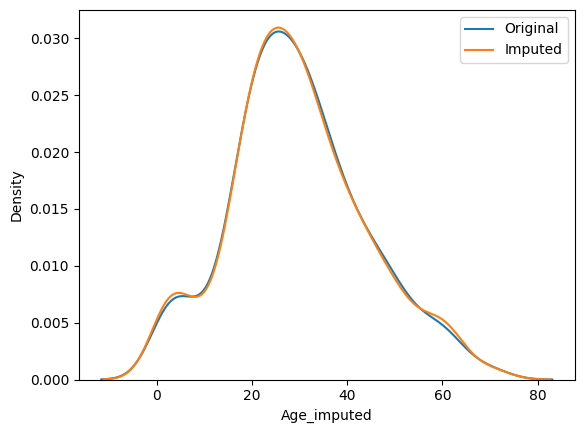

In [27]:
sns.distplot(X_train['Age'],label = 'Original' , hist = False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed' , hist = False)
plt.legend()
plt.show()

In [28]:
print('Original Variance', X_train['Age'].var())
print('Imputed Variance', X_train['Age_imputed'].var())

Original Variance 204.3495133904614
Imputed Variance 208.73481659614535


In [29]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,58.880659
Age,71.512440,204.349513,204.349513
Age_imputed,58.880659,204.349513,208.734817


<Axes: >

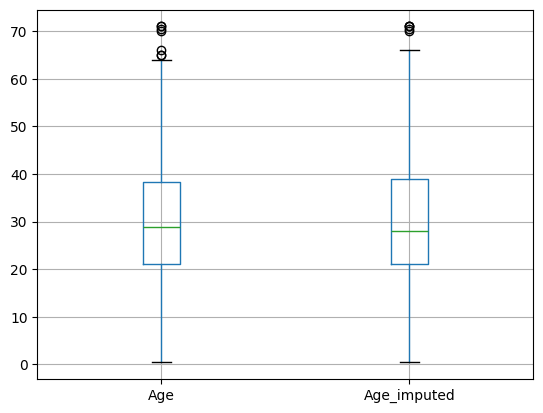

In [31]:
X_train[[ 'Age' , 'Age_imputed']].boxplot()

In [38]:
sampled_value = X_train['Age'].dropna().sample(1,random_state = int(observation['Fare']))

#just to give same outputs after even giving random numbers --> Future precaution while working on a website


NameError: name 'observation' is not defined

In [39]:
data = pd.read_csv('/content/train.csv', usecols = ['GarageQual' , 'FireplaceQu' , 'SalePrice'])

In [40]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [41]:
data.isnull().mean() *100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [42]:
X = data
y = data['SalePrice']

In [43]:
X_train, X_test , y_train , y_test = train_test_split(X,y , test_size = 0.2 , random_state = 2)

In [44]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [45]:

X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
961,TA,TA,272000,TA,TA
238,NaN,TA,318000,TA,NaN
1103,Fa,TA,159500,TA,Fa
551,NaN,TA,112500,TA,NaN
378,Ex,TA,394432,TA,Ex


In [46]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values

X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values

X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_test['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/tmp/ipykernel_5189/1585991894.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
/tm

In [47]:
temp = pd.concat(
    [
        X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_imputed'].value_counts() / len(X_train)
    ],
    axis = 1)

temp.columns = ['Original' , 'Imputed']
temp


,Original,Imputed
TA,0.951043,0.950342
Fa,0.037171,0.036815
Gd,0.009973,0.011130
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [48]:
temp = pd.concat([
    X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
    X_train['FireplaceQu_imputed'].value_counts() / len(df)
],
axis =1)

temp.columns = ['Original' , 'Imputed']
temp

,Original,Imputed
Gd,0.494272,0.650954
TA,0.412439,0.536476
Fa,0.040917,0.052750
Po,0.027823,0.038159
Ex,0.024550,0.032548


/tmp/ipykernel_5189/1626236559.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'] , hist = False , label = category)
/tmp/ipykernel_5189/1626236559.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['Fir

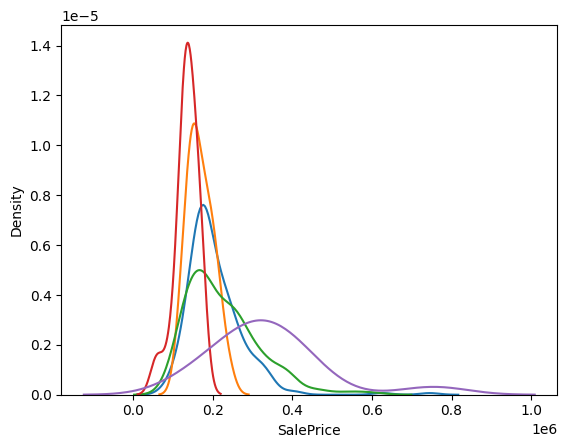

In [49]:
for category in X_train['GarageQual'].dropna().unique():
  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'] , hist = False , label = category)
plt.show()

/tmp/ipykernel_5189/4025710454.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'] , hist = False , label = category)
/tmp/ipykernel_5189/4025710454.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['Fir

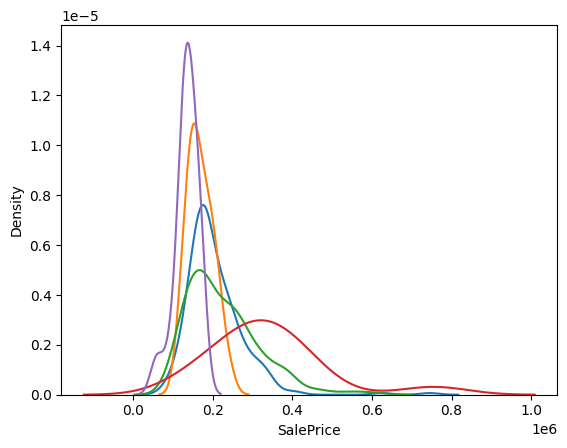

In [50]:
for category in X_train['FireplaceQu'].dropna().unique():
  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'] , hist = False , label = category)
plt.show()